# Jahanvi

# CU23230001

# Labsheet 8
Title: Implementation of EM Algorithm and K-Means Clustering

 Task 1: Dataset Loading

In [ ]:
!pip install streamlit pyngrok

In [ ]:
!ngrok config add-authtoken 3CtTChFBWLKFe7L3Hbe4lM54p10_4QfJEUviRBWrvdjPW4KHd

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
# !pkill -f ngrok
# !pkill -f streamlit

In [ ]:
from pyngrok import ngrok

!streamlit run app.py &>/dev/null &

public_url = ngrok.connect(8501)
public_url

<NgrokTunnel: "https://straining-italics-degraded.ngrok-free.dev" -> "http://localhost:8501">

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [ ]:
# Load dataset from CSV file
df = pd.read_csv("/content/heart_disease - heart_disease.csv")

In [ ]:
# Display dataset structure
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:\n", df.head())

Dataset Shape: (10000, 21)

First 5 Rows:
     Age  Gender  Blood Pressure  Cholesterol Level Exercise Habits Smoking  \
0  56.0    Male           153.0              155.0            High     Yes   
1  69.0  Female           146.0              286.0            High      No   
2  46.0    Male           126.0              216.0             Low      No   
3  32.0  Female           122.0              293.0            High     Yes   
4  60.0    Male           166.0              242.0             Low     Yes   

  Family Heart Disease Diabetes        BMI High Blood Pressure  ...  \
0                  Yes       No  24.991591                 Yes  ...   
1                  Yes      Yes  25.221799                  No  ...   
2                   No       No  29.855447                  No  ...   
3                  Yes       No  24.130477                 Yes  ...   
4                  Yes      Yes  20.486289                 Yes  ...   

  High LDL Cholesterol Alcohol Consumption Stress Level Sleep

In [ ]:
# Feature names and data types
print("\nFeature Names:\n", df.columns)
print("\nData Types:\n", df.dtypes)



Feature Names:
 Index(['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level',
       'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI',
       'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Alcohol Consumption', 'Stress Level', 'Sleep Hours',
       'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar',
       'CRP Level', 'Homocysteine Level', 'Heart Disease Status'],
      dtype='object')

Data Types:
 Age                     float64
Gender                   object
Blood Pressure          float64
Cholesterol Level       float64
Exercise Habits          object
Smoking                  object
Family Heart Disease     object
Diabetes                 object
BMI                     float64
High Blood Pressure      object
Low HDL Cholesterol      object
High LDL Cholesterol     object
Alcohol Consumption      object
Stress Level             object
Sleep Hours             float64
Sugar Consumption        object
Triglyceride L

In [ ]:
# Statistical Summary
print("\nStatistical Summary:\n", df.describe())


Statistical Summary:
                Age  Blood Pressure  Cholesterol Level          BMI  \
count  9971.000000     9981.000000        9970.000000  9978.000000   
mean     49.296259      149.757740         225.425577    29.077269   
std      18.193970       17.572969          43.575809     6.307098   
min      18.000000      120.000000         150.000000    18.002837   
25%      34.000000      134.000000         187.000000    23.658075   
50%      49.000000      150.000000         226.000000    29.079492   
75%      65.000000      165.000000         263.000000    34.520015   
max      80.000000      180.000000         300.000000    39.996954   

       Sleep Hours  Triglyceride Level  Fasting Blood Sugar    CRP Level  \
count  9975.000000         9974.000000          9978.000000  9974.000000   
mean      6.991329          250.734409           120.142213     7.472201   
std       1.753195           87.067226            23.584011     4.340248   
min       4.000605          100.000000    

 Task 2: Data Preprocessing


In [ ]:
# Checking for missing values
missing_info = df.isnull().sum()
# Dropping rows with missing values to ensure clean clusters
df_cleaned = df.dropna()

In [ ]:
# 2. Select relevant features for clustering
# Selecting continuous numeric features that are typically used for clustering heart disease data
features = ['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours', 'Triglyceride Level']
X = df_cleaned[features]

In [ ]:
# 3. Normalize/Standardize the dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Prepare summary of preprocessing
preprocessing_summary = {
    "Original Rows": len(df),
    "Rows after dropping NaNs": len(df_cleaned),
    "Features Selected": features,
    "Missing Values per Column": missing_info[missing_info > 0].to_dict()
}
print(preprocessing_summary)

{'Original Rows': 10000, 'Rows after dropping NaNs': 7067, 'Features Selected': ['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours', 'Triglyceride Level'], 'Missing Values per Column': {'Age': 29, 'Gender': 19, 'Blood Pressure': 19, 'Cholesterol Level': 30, 'Exercise Habits': 25, 'Smoking': 25, 'Family Heart Disease': 21, 'Diabetes': 30, 'BMI': 22, 'High Blood Pressure': 26, 'Low HDL Cholesterol': 25, 'High LDL Cholesterol': 26, 'Alcohol Consumption': 2586, 'Stress Level': 22, 'Sleep Hours': 25, 'Sugar Consumption': 30, 'Triglyceride Level': 26, 'Fasting Blood Sugar': 22, 'CRP Level': 26, 'Homocysteine Level': 20}}


Task 3: EM Algorithm (Gaussian Mixture Model)

In [ ]:
# Specifying 3 clusters for deeper insight into potential risk groups
n_clusters = 3
gmm = GaussianMixture(n_components=n_clusters, random_state=42)
gmm.fit(X_scaled)

GaussianMixture(n_components=3, random_state=42)

In [ ]:
# Predict Cluster Labels
cluster_labels = gmm.predict(X_scaled)
df_cleaned = df_cleaned.copy()
df_cleaned['EM_Cluster_Labels'] = cluster_labels

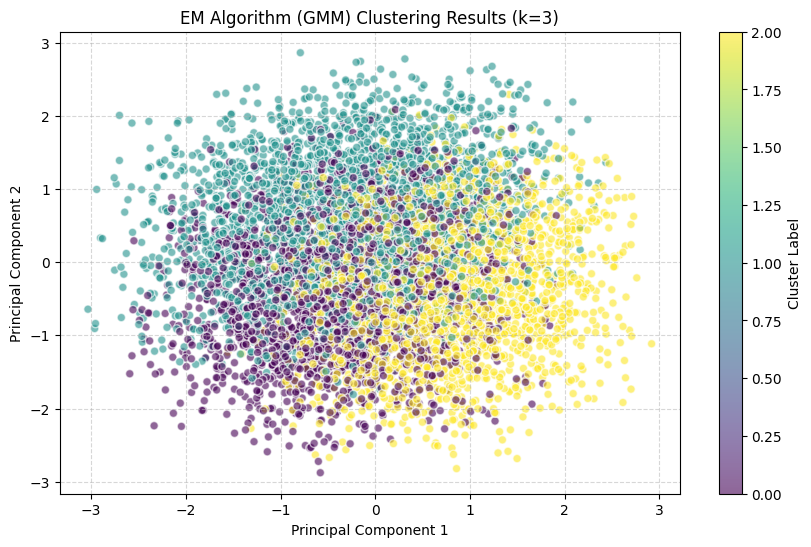

In [ ]:
#  Visualize the clustering result using PCA for 2D representation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6, edgecolors='w')
plt.title(f'EM Algorithm (GMM) Clustering Results (k={n_clusters})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Cluster Label')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('em_clustering_plot.png')

In [ ]:
# Display first few predicted labels
print("First 10 Predicted Cluster Labels:")
print(cluster_labels[:10])

First 10 Predicted Cluster Labels:
[2 0 2 1 2 0 1 2 0 0]


Task 4: K-Means Algorithm

In [ ]:
# Using the same number of clusters (k=3) as used in Task 3 for consistency
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10)
kmeans.fit(X_scaled)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [ ]:
# Assign Cluster Labels
km_labels = kmeans.labels_
df_cleaned = df_cleaned.copy()
df_cleaned['KMeans_Cluster_Labels'] = km_labels

/tmp/ipykernel_1456/3810029973.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


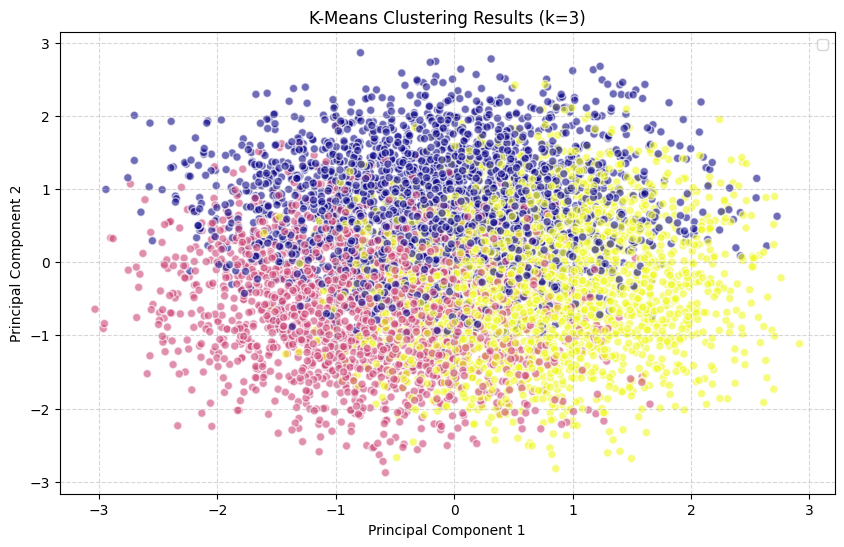

In [ ]:
# Visualize the clustering result using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, cmap='plasma', alpha=0.6, edgecolors='w')
plt.title(f'K-Means Clustering Results (k={n_clusters})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('kmeans_clustering_plot.png')

In [ ]:
# Display result summary
print(f"K-Means Inertia: {kmeans.inertia_}")
print("First 10 Predicted Cluster Labels (K-Means):")
print(km_labels[:10])

K-Means Inertia: 33667.19759803672
First 10 Predicted Cluster Labels (K-Means):
[2 0 2 0 2 1 1 2 1 1]


Task 5: Performance Comparison

In [ ]:
# Apply Models
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)
km_inertia = kmeans.inertia_
km_score = silhouette_score(X_scaled, km_labels)

gmm = GaussianMixture(n_components=n_clusters, random_state=42)
gmm.fit(X_scaled)
em_labels = gmm.predict(X_scaled)
em_score = silhouette_score(X_scaled, em_labels)

# Performance Comparison output
print(f"EM Silhouette Score: {em_score:.4f}")
print(f"K-Means Silhouette Score: {km_score:.4f}")
print(f"K-Means Inertia: {km_inertia:.4f}")

EM Silhouette Score: 0.1102
K-Means Silhouette Score: 0.1149
K-Means Inertia: 33667.1976


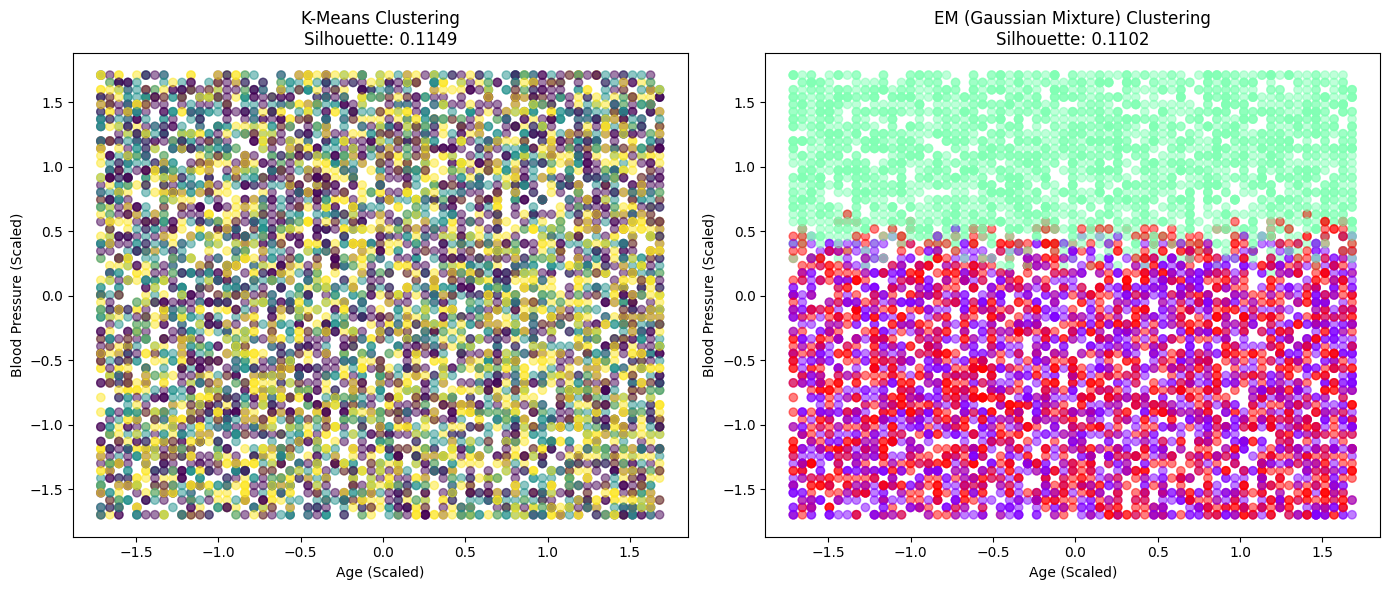

In [ ]:
# Visualization
plt.figure(figsize=(14, 6))

# KMeans Plot
plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=km_labels, cmap='viridis', alpha=0.5)
plt.title(f"K-Means Clustering\nSilhouette: {km_score:.4f}")
plt.xlabel("Age (Scaled)")
plt.ylabel("Blood Pressure (Scaled)")

# EM Plot
plt.subplot(1, 2, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=em_labels, cmap='rainbow', alpha=0.5)
plt.title(f"EM (Gaussian Mixture) Clustering\nSilhouette: {em_score:.4f}")
plt.xlabel("Age (Scaled)")
plt.ylabel("Blood Pressure (Scaled)")

plt.tight_layout()
plt.savefig('heart_disease_comparison.png')
plt.show()

Conclusion & Comments

1. Performance: K-Means achieved a slightly higher Silhouette Score (0.1149) compared to EM (0.1102), though both scores are low due to significant data overlap.

2. Flexibility: The EM Algorithm is superior for medical data as it uses "soft" probabilistic clustering, allowing patients to belong to multiple risk categories simultaneously.

3. Cluster Nature: The low scores indicate that heart disease risk factors exist on a continuous spectrum rather than in isolated groups.

4. Efficiency: K-Means is faster and better for initial exploration, while EM provides deeper insights into the underlying distribution of the dataset.

# Deploy

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# --- 1. Page Configuration & Branding ---
st.set_page_config(page_title="Heart Disease Clustering Dashboard", layout="wide")

# Enhanced CSS: Fixes visibility for image_0e2134.png & adds professional polish
st.markdown("""
    <style>
    [data-testid="stMetricValue"] {
        color: #1e3a8a !important;
        font-weight: 700 !important;
    }
    [data-testid="stMetricLabel"] {
        color: #475569 !important;
        font-size: 1.1rem !important;
    }
    .stMetric {
        background-color: #ffffff !important;
        border: 2px solid #e2e8f0 !important;
        padding: 20px !important;
        border-radius: 12px !important;
    }
    .main { background-color: #f8fafc; }
    h1 { color: #1e3a8a; border-bottom: 2px solid #1e3a8a; padding-bottom: 10px; }
    h2, h3 { color: #1e40af; }
    </style>
    """, unsafe_allow_html=True)

# --- 2. Data Processing Pipeline ---
@st.cache_data
def load_and_prep():
    # Loading the heart disease dataset
    df = pd.read_csv('heart_disease - heart_disease.csv')
    df_cleaned = df.dropna()
    features = ['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours', 'Triglyceride Level']
    X = df_cleaned[features]

    # Standardization for clustering
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return df_cleaned, X_scaled, features

try:
    df_clean, X_scaled, feat_list = load_and_prep()

    st.title("🫀 Heart Disease Patient Segmentation Dashboard")
    st.markdown("An advanced comparison of **K-Means** (Centroid-based) and **Expectation-Maximization** (Distribution-based) methodologies.")

    # --- 3. Sidebar & Control Panel ---
    st.sidebar.header("🛠 Model Configuration")
    n_clusters = st.sidebar.select_slider("Target Segments (k)", options=[2, 3, 4, 5], value=3)
    st.sidebar.info(f"Analyzing Features: {', '.join(feat_list)}")
    run_btn = st.sidebar.button("🚀 Run Comparative Analysis", use_container_width=True)

    # Initial View: Data Preview
    if not run_btn:
        st.subheader("📋 Dataset Overview")
        st.dataframe(df_clean.head(10), use_container_width=True)
        st.info("Adjust the clusters in the sidebar and click 'Run Analysis' to see the visuals.")

    else:
        # --- 4. Model Execution ---
        # K-Means
        km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10).fit(X_scaled)
        km_sil = silhouette_score(X_scaled, km.labels_)

        # EM (Gaussian Mixture Model)
        gmm = GaussianMixture(n_components=n_clusters, random_state=42).fit(X_scaled)
        gmm_labels = gmm.predict(X_scaled)
        gmm_sil = silhouette_score(X_scaled, gmm_labels)

        # --- 5. Metrics Section ---
        st.subheader("📊 Performance Analytics")
        m_col1, m_col2, m_col3 = st.columns(3)

        m_col1.metric(label="K-Means Silhouette", value=f"{km_sil:.4f}", delta="Distance Based")
        m_col2.metric(label="EM (GMM) Silhouette", value=f"{gmm_sil:.4f}", delta="Distribution Based")
        m_col3.metric(label="Model Inertia (KM)", value=f"{int(km.inertia_)}")

        st.markdown("---")

        # --- 6. Visualizations (PCA) ---
        st.subheader("📍 Cluster Visualization (PCA 2D Projection)")
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_scaled)

        v_col1, v_col2 = st.columns(2)

        with v_col1:
            fig1, ax1 = plt.subplots(figsize=(8, 6))
            scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=km.labels_, cmap='viridis', s=20, alpha=0.6)
            ax1.set_title("K-Means: Geometric Segments", fontsize=14)
            ax1.set_xlabel("PC 1")
            ax1.set_ylabel("PC 2")
            st.pyplot(fig1)

        with v_col2:
            fig2, ax2 = plt.subplots(figsize=(8, 6))
            scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap='plasma', s=20, alpha=0.6)
            ax2.set_title("EM: Probabilistic Segments", fontsize=14)
            ax2.set_xlabel("PC 1")
            ax2.set_ylabel("PC 2")
            st.pyplot(fig2)

        st.markdown("---")

        # --- 7. Technical Table ---
        st.subheader("📝 Methodological Comparison Summary")
        comparison_data = {
            "Parameter": ["Algorithm Basis", "Cluster Geometry", "Membership Type", "Silhouette Score"],
            "K-Means Clustering": ["Centroid (Euclidean)", "Spherical", "Hard Assignment", f"{km_sil:.4f}"],
            "EM (GMM)": ["Gaussian (Probability)", "Ellipsoidal", "Soft Assignment", f"{gmm_sil:.4f}"]
        }
        st.table(pd.DataFrame(comparison_data))

        st.success(f"Analysis complete for {n_clusters} patient segments.")

except Exception as e:
    st.error(f"Configuration Error: {e}")

Overwriting app.py
